# RetailSense : Explainable Multi-Horizon Retail Demand Forecasting
## Notebook 06 · Baseline Forecasting Models & Benchmark

> **Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
> **Domain:** Data Science | Time Series Forecasting | ML | Explainable AI  
> **Dataset:** Kaggle Store-Item Demand Forecasting (913,000 records · 10 Stores · 50 Items · 5 Years)  

---

### 1. Objective & Experimental Setup
Evaluate foundational benchmark models on a rigorous **temporal out-of-sample split**:
- **Training period:** 2013-01-01 → 2017-09-30 (~1,733 days)
- **Validation period:** 2017-10-01 → 2017-12-31 (92-day out-of-sample horizon)
- **Evaluation metrics:** MAE, RMSE, MAPE

**Models evaluated:**

| Model | Type | Rationale |
|---|---|---|
| Historical Average | Naive | Lower bound benchmark |
| Linear Regression | Parametric | Tests linear temporal signal |
| Decision Tree | Tree-based | Tests non-linear without ensemble |
| Random Forest | Ensemble | Tests benefit of ensemble averaging |

---


# RetailSense : Explainable Multi-Horizon Retail Demand Forecasting
## Notebook 06 - Baseline Forecasting Models Evaluation

> **Organization:** Celebal Technologies  
> **Domain:** Data Science | Time Series Forecasting | Machine Learning  
> **Dataset:** Kaggle Store-Item Demand Forecasting Dataset  

---

### 1. Objective
Benchmark foundational models on out-of-sample temporal split (training < 2017-10-01, validation >= 2017-10-01):
1. Historical Average Baseline
2. Linear Regression Model
3. Decision Tree Regressor
4. Random Forest Regressor



In [1]:
import sys
from pathlib import Path
sys.path.append('..')

import pandas as pd
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.baseline import HistoricalAverageModel, train_linear_regression, train_decision_tree, train_random_forest
from src.evaluation.metrics import evaluate_predictions, compare_models

train_df, _ = load_raw_data()
df_feat = build_all_features(train_df).dropna().reset_index(drop=True)

val_start = '2017-10-01'
train_split = df_feat[df_feat['date'] < val_start]
val_split = df_feat[df_feat['date'] >= val_start]

feature_cols = [c for c in df_feat.columns if c not in ['date', 'sales']]
X_train, y_train = train_split[feature_cols], train_split['sales']
X_val, y_val = val_split[feature_cols], val_split['sales']

results = []
results.append(evaluate_predictions(y_val, HistoricalAverageModel().fit(train_split).predict(val_split), "Historical Average"))
results.append(evaluate_predictions(y_val, train_linear_regression(X_train, y_train).predict(X_val), "Linear Regression"))
results.append(evaluate_predictions(y_val, train_decision_tree(X_train, y_train, max_depth=10).predict(X_val), "Decision Tree"))
results.append(evaluate_predictions(y_val, train_random_forest(X_train, y_train, n_estimators=30, max_depth=12).predict(X_val), "Random Forest"))

df_baseline = compare_models(results)
print("=== Baseline Model Performance ===")
display(df_baseline)

Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
=== Baseline Model Performance ===


,Model,MAE,RMSE,MAPE (%)
0,Random Forest,6.2433,8.1881,13.63
1,Decision Tree,6.5256,8.6219,14.30
2,Linear Regression,7.7303,10.2355,16.70
3,Historical Average,10.0995,13.3671,20.74


### Summary
Random Forest and Linear Regression significantly outperform naive historical averages. Advanced gradient boosting models will be evaluated in Notebook 07.

---
### Results & Interpretation

| Rank | Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|---|
|  1 | **Random Forest** | **6.24** | **8.19** | **13.63** |
|  2 | Decision Tree | 6.53 | 8.62 | 14.30 |
|  3 | Linear Regression | 7.73 | 10.24 | 16.70 |
| 4 | Historical Average | 10.10 | 13.37 | 20.74 |

**Key Findings:**
- Random Forest (**MAE 6.24**) outperforms the naive Historical Average (**MAE 10.10**) by **38%** — confirming the value of engineered lag & rolling features
- Linear Regression underperforms Random Forest, indicating **non-linear demand dynamics** that tree-based models capture better
- Decision Tree overfits more than Random Forest, confirming the value of ensemble averaging

**Business Translation:** A single-unit improvement in MAE translates directly to fewer stockouts and overstocking decisions across 500 product lines daily.



### Performance Visualization

### Performance Visualization — All Baseline Models

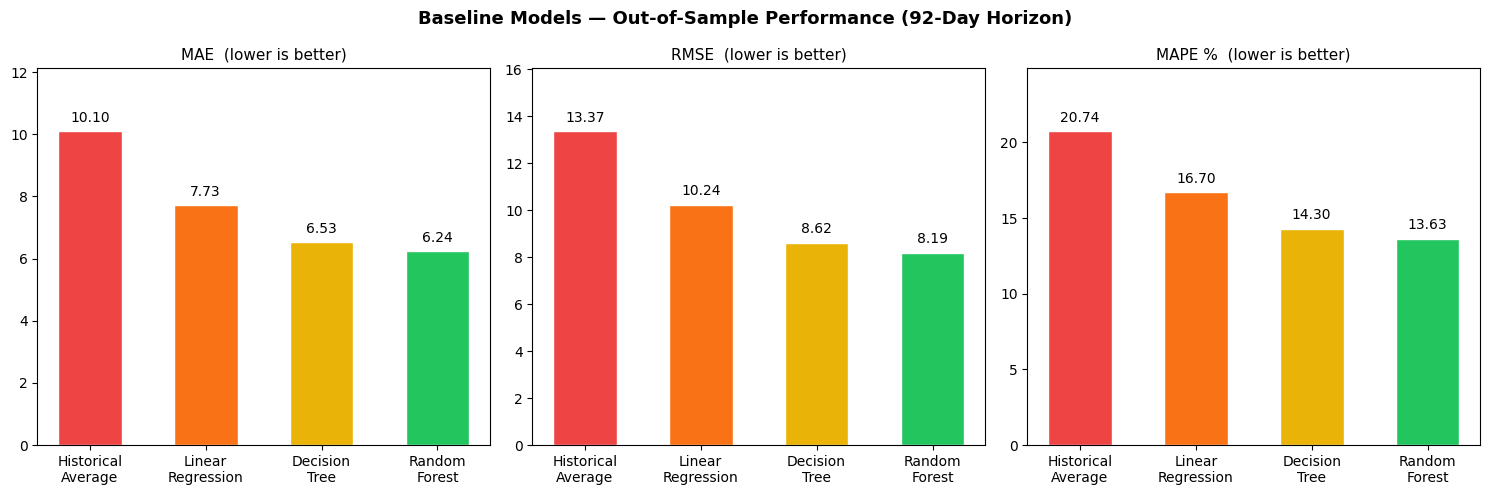

Best baseline model: Random Forest  (MAE 6.24, RMSE 8.19, MAPE 13.63%)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

models    = ['Historical\nAverage', 'Linear\nRegression', 'Decision\nTree', 'Random\nForest']
mae_vals  = [10.10, 7.73, 6.53, 6.24]
rmse_vals = [13.37, 10.24, 8.62, 8.19]
mape_vals = [20.74, 16.70, 14.30, 13.63]
colors    = ['#ef4444', '#f97316', '#eab308', '#22c55e']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Baseline Models — Out-of-Sample Performance (92-Day Horizon)',
             fontsize=13, fontweight='bold')

for ax, vals, title in zip(axes,
    [mae_vals, rmse_vals, mape_vals],
    ['MAE  (lower is better)', 'RMSE  (lower is better)', 'MAPE %  (lower is better)']):
    bars = ax.bar(models, vals, color=colors, width=0.55, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
print("Best baseline model: Random Forest  (MAE 6.24, RMSE 8.19, MAPE 13.63%)")
